C:\Users\BONETTI\AppData\Local\Temp\ipykernel_2884\214341617.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


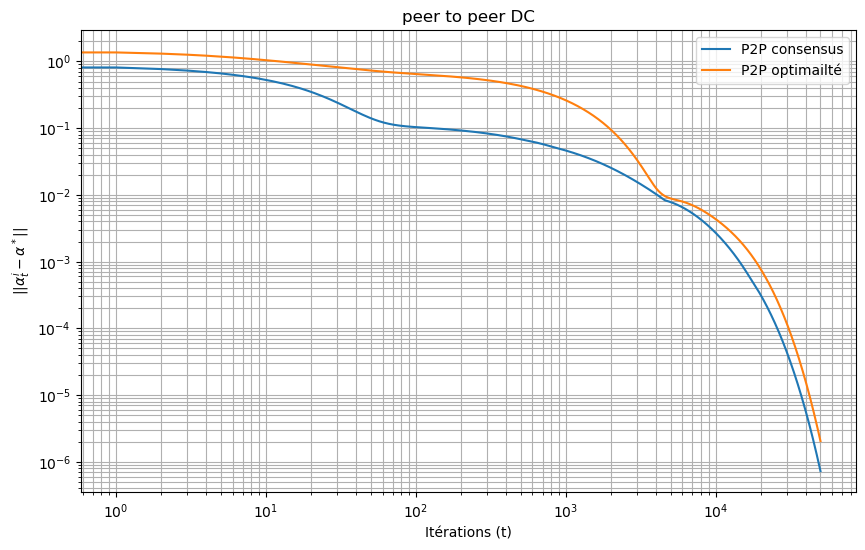

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me

#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 50000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    

#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8


#graphe complet 
W3 = np.ones((a, a)) / a




### 1. on doit avoir un graphe non dirige 
# ici W3 (graphe fully connected) est non dirige --> agent i communqiue avec j et inversement 

###2. edges = aretes 
# les variables lambda_ij sont sur les aretes et on indexe ces aretes par j<i pour ne pas les compter deux fois 
# pour W3 : chaque noeud est connecte à tous les autres 
# l' ensemble E contient donc a(a-1)/2 paires 

### poids de Wij 
# ici il faut juste que nos poids soit positifs (presence d'une arete)
# ici avec W3, on a des Wii non nuls, il faudra donc les ignorer lors de la creation de lambda_ij car on regarde que i ~j ( i diff de j )







## pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W3[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
            

#on va débuter le peer to peer  
# 1. on initialise 
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul
erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]

#pas 
eta=0.001
alpha_k=0.01



for t in range (n_iter):
    
    #computation step - chaque agent doit trouver son alpha_p2p 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W3[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        b_i= Ki.T @ yi - dual_sum
        alpha_p2p[i] = np.linalg.solve(A_i, b_i)
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
        
    # gap de consensus et non d'optimalité 
    mean_alpha = np.mean(alpha_p2p, axis=0)
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))
    erreur_p2p_optimalite.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
              
       
        
    
    
   
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_p2p_consensus, label='P2P consensus')
plt.loglog(erreur_p2p_optimalite, label='P2P optimailté')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('peer to peer DC')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


le consensus mesure à quel point les agnets sont d'accord entre eux 
-  --> si tend vers 0 : agents ont converge vers le meme alpha 
- on peut prendre cette metrique pour le n grand (a verifier )!!!!!!!!!!!!!!!! 

- pour le DGD - on converge rapidement vers consensus mais ca reste loin de l'optimum normalement . le gap stagne à cause du biais ( on le voit sur nos figures d'avant)
- pour le peer to peer et GT : consensus et optimalité se rejoignent (pour les deux methodes, le gap peut descencdre tres bas )

- pour n grand (passer au consensus): tester si ca macrhe 

**different graphs** 


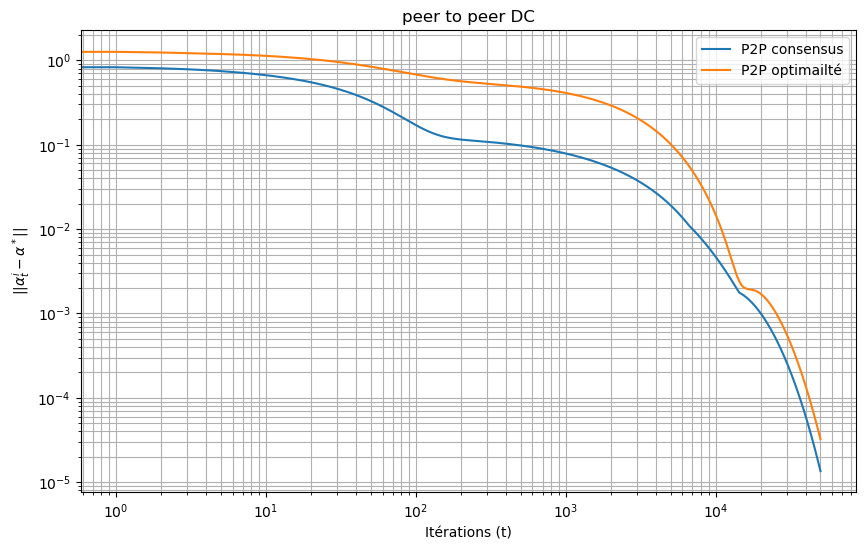

In [ ]:

#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    

## pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
            

#on va débuter le peer to peer  
# 1. on initialise 
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul
erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]

#pas 
eta=0.001
alpha_k=0.01



for t in range (n_iter):
    
    #computation step - chaque agent doit trouver son alpha_p2p 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        b_i= Ki.T @ yi - dual_sum
        alpha_p2p[i] = np.linalg.solve(A_i, b_i)
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
        
    # gap de consensus et non d'optimalité 
    mean_alpha = np.mean(alpha_p2p, axis=0)
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))
    erreur_p2p_optimalite.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
              
       
        
    
    
   
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_p2p_consensus, label='P2P consensus')
plt.loglog(erreur_p2p_optimalite, label='P2P optimailté')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('peer to peer DC graphe Graphe en cycle ')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


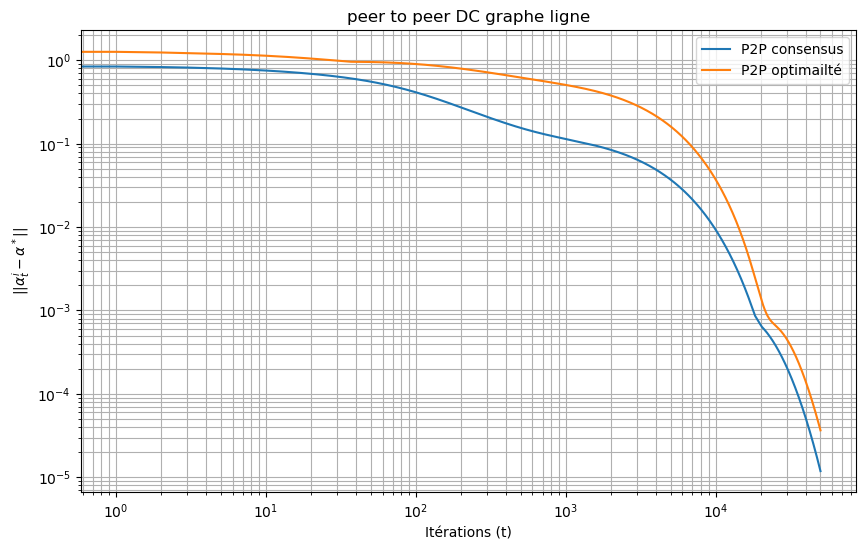

In [ ]:



#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8









# pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W2[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
            

##on va débuter le peer to peer  
# 1. on initialise 
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul
erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]

#pas 
eta=0.001
alpha_k=0.01



for t in range (n_iter):
    
    #computation step - chaque agent doit trouver son alpha_p2p 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W2[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        b_i= Ki.T @ yi - dual_sum
        alpha_p2p[i] = np.linalg.solve(A_i, b_i)
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
        
    # gap de consensus et non d'optimalité 
    mean_alpha = np.mean(alpha_p2p, axis=0)
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))
    erreur_p2p_optimalite.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
              
       
        
    
    
   
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_p2p_consensus, label='P2P consensus')
plt.loglog(erreur_p2p_optimalite, label='P2P optimailté')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('peer to peer DC graphe ligne')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


**visualisation**

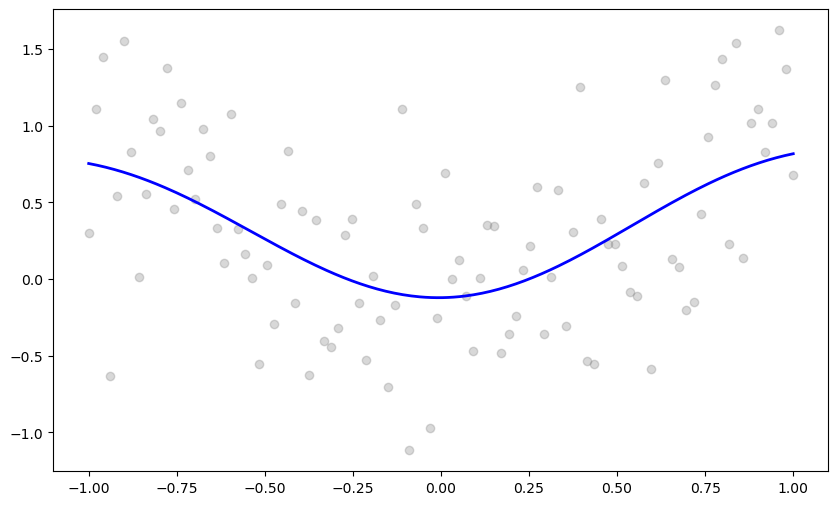

In [ ]:
#visualisation de la fonction apprise 

nt = 250
x_prime = np.linspace(-1, 1, nt) # 
K_test = Cov2(x_prime, x_m) 

plt.figure(figsize=(10, 6))

#On affiche les données brutes
plt.scatter(x, y, alpha=0.3, label='Données bruitées', color='gray')

#On affiche la solution prédite par l'agent 0 
y_pred_dgd = K_test @ alpha_p2p[0] 
plt.plot(x_prime, y_pred_dgd, label='Fonction apprise (DGD)', color='blue', linewidth=2)



**comparaison avec DGD et GT**

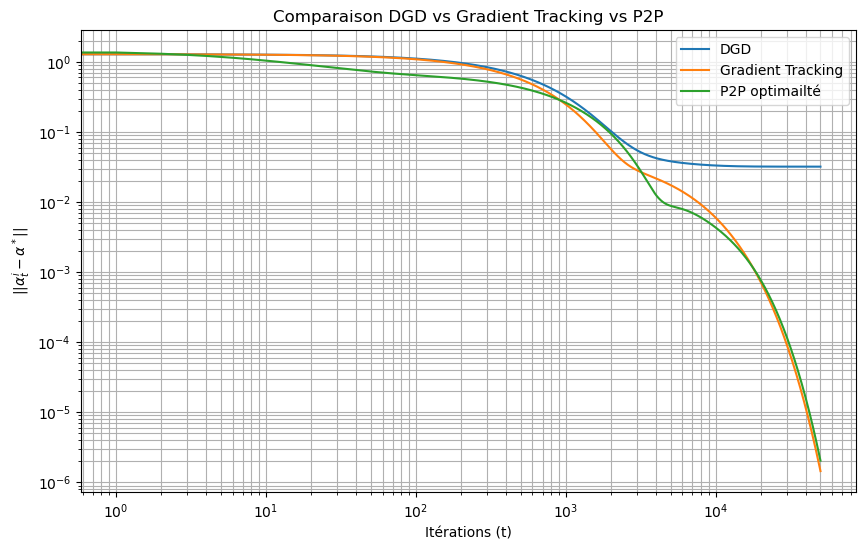

In [2]:
#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 





# pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W3[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul


erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]
erreur_dgd=[]
erreur_gt=[]


#pas 
eta=0.001
alpha_k=0.01



# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]










for t in range (n_iter):
    
    
    
    ######### DGD ##########################
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    
    
    
    ########################### GT ##########################
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W3[i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W3[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    
    
    
    
    ####################### P2P 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W3[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        b_i= Ki.T @ yi - dual_sum
        alpha_p2p[i] = np.linalg.solve(A_i, b_i)
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
    
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    # gap de consensus et non d'optimalité 
    mean_alpha = np.mean(alpha_p2p, axis=0)
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))
    erreur_p2p_optimalite.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.loglog(erreur_p2p_optimalite, label='P2P optimailté')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking vs P2P')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


        
    
    
   
    


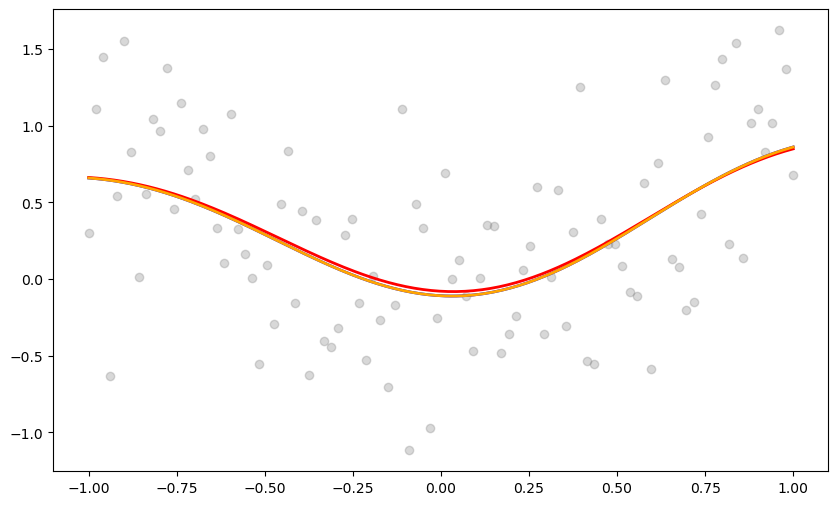

In [4]:
#visualisation de la fonction apprise 

nt = 250
x_prime = np.linspace(-1, 1, nt) # 
K_test = Cov2(x_prime, x_m) 

plt.figure(figsize=(10, 6))

#On affiche les données brutes
plt.scatter(x, y, alpha=0.3, label='Données bruitées', color='gray')

#On affiche la solution prédite par l'agent 0 
y_pred_p2p = K_test @ alpha_p2p[0] 
plt.plot(x_prime, y_pred_p2p, label='Fonction apprise (p2p)', color='blue', linewidth=2)
y_pred_dgd = K_test @ alpha_dgd[0] 
plt.plot(x_prime, y_pred_dgd, label='Fonction apprise (DGD)', color='red', linewidth=2)
y_pred_gt = K_test @ alpha_gt[0] 
plt.plot(x_prime, y_pred_gt, label='Fonction apprise (GT)', color='orange', linewidth=2)



si on augmente n 

C:\Users\BONETTI\AppData\Local\Temp\ipykernel_6744\1794858172.py:18: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


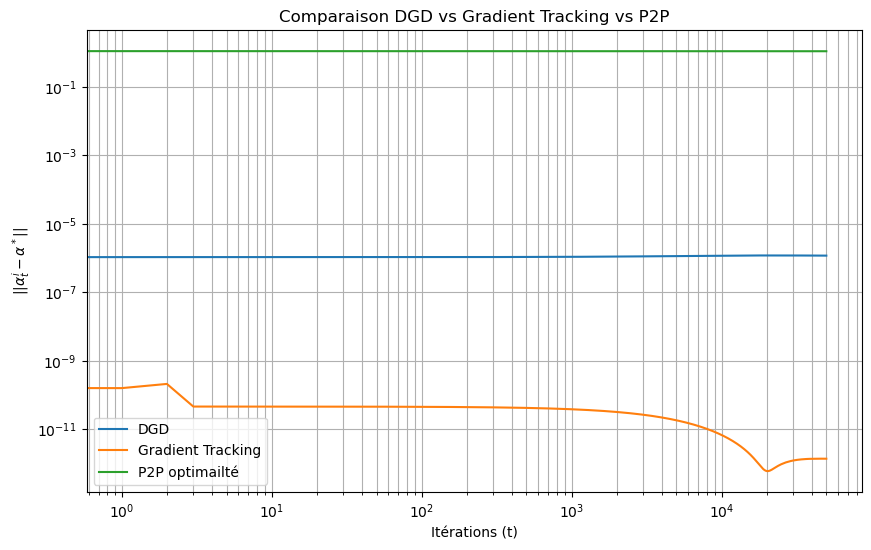

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 10000, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 50000   # Nombre d'itérations


n_i= n//a
# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# # solution pour le kernel ridge est un alpha * 
# a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
# b_star=Knm.T@y
# alpha_star=np.linalg.solve(a_star,b_star)




#graphe complet 
W3 = np.ones((a, a)) / a



#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 





# pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W3[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul


#erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]
erreur_dgd=[]
erreur_gt=[]


#pas 
eta=1e-8
alpha_k=1e-8



# INITIALISATION
for i in range(a):
    idx_loc = range(i*n_i, (i+1)*n_i)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]


inv_Ai = []
for i in range(a):
    idx_loc = range(i*n_i, (i+1)*n_i)
    Ki = Knm[idx_loc, :]
    Ai = (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
    inv_Ai.append(np.linalg.inv(Ai)) # On stocke l'inverse pour aller très vite







for t in range (n_iter):
    
    
    
    ######### DGD ##########################
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*n_i, (i+1)*n_i)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    
    
    
    ########################### GT ##########################
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*n_i, (i+1)*n_i)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W3[i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W3[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    
    
    
    
    ####################### P2P 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*n_i, (i+1)*n_i)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W3[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        #A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        bi_local= Ki.T @ yi - dual_sum
        alpha_p2p[i] = inv_Ai[i] @ bi_local
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
    mean_alpha_dgd= np.mean(alpha_dgd, axis=0)
    mean_alpha_gt= np.mean(alpha_gt, axis=0)
    mean_alpha = np.mean(alpha_p2p, axis=0)
    
    
    #erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))
    #erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    erreur_dgd.append(np.max([np.linalg.norm(alpha_dgd[i] - mean_alpha_dgd) for i in range(a)]))
    erreur_gt.append(np.max([np.linalg.norm(alpha_gt[i] - mean_alpha_gt) for i in range(a)]))
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))

plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.loglog(erreur_p2p_consensus, label='P2P optimailté')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking vs P2P')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


        
    
    
   
    
